# Loan Approval Prediction (Kaggle Playground S4E10)

Mi entrega para el challenge de predicción de aprobación de préstamos.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from features import (
    CATEGORICAL_COLS,
    NUMERIC_COLS,
    TARGET,
    build_model_frame,
    feature_columns,
    load_data,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
RANDOM_STATE = 42


## Cargando los datos

In [2]:
train_raw, test_raw, sample_submission = load_data("../data")

print("Train:", train_raw.shape)
print("Test: ", test_raw.shape)
train_raw.head()


Train: (58645, 13)
Test:  (39098, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
train_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [4]:
# Valores nulos por columna (train y test)
print("Nulos en train:")
print(train_raw.isna().sum())
print("\nNulos en test:")
print(test_raw.isna().sum())


Nulos en train:
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

Nulos en test:
id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## ¿Cómo está repartido el target?

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64


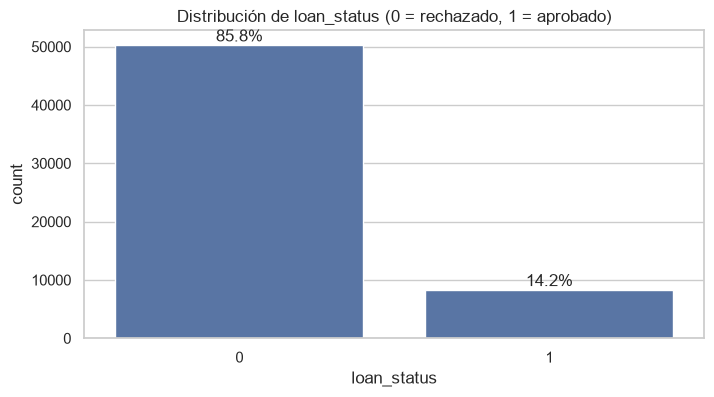

In [5]:
target_counts = train_raw[TARGET].value_counts(normalize=True)
print(target_counts)

ax = sns.countplot(x=TARGET, data=train_raw)
ax.set_title("Distribución de loan_status (0 = rechazado, 1 = aprobado)")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(train_raw):.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


Bastante desbalanceado: solo ~14% de las solicitudes se aprueban.
Con esto en mente, voy a usar folds estratificados para la validación


## Variables numéricas

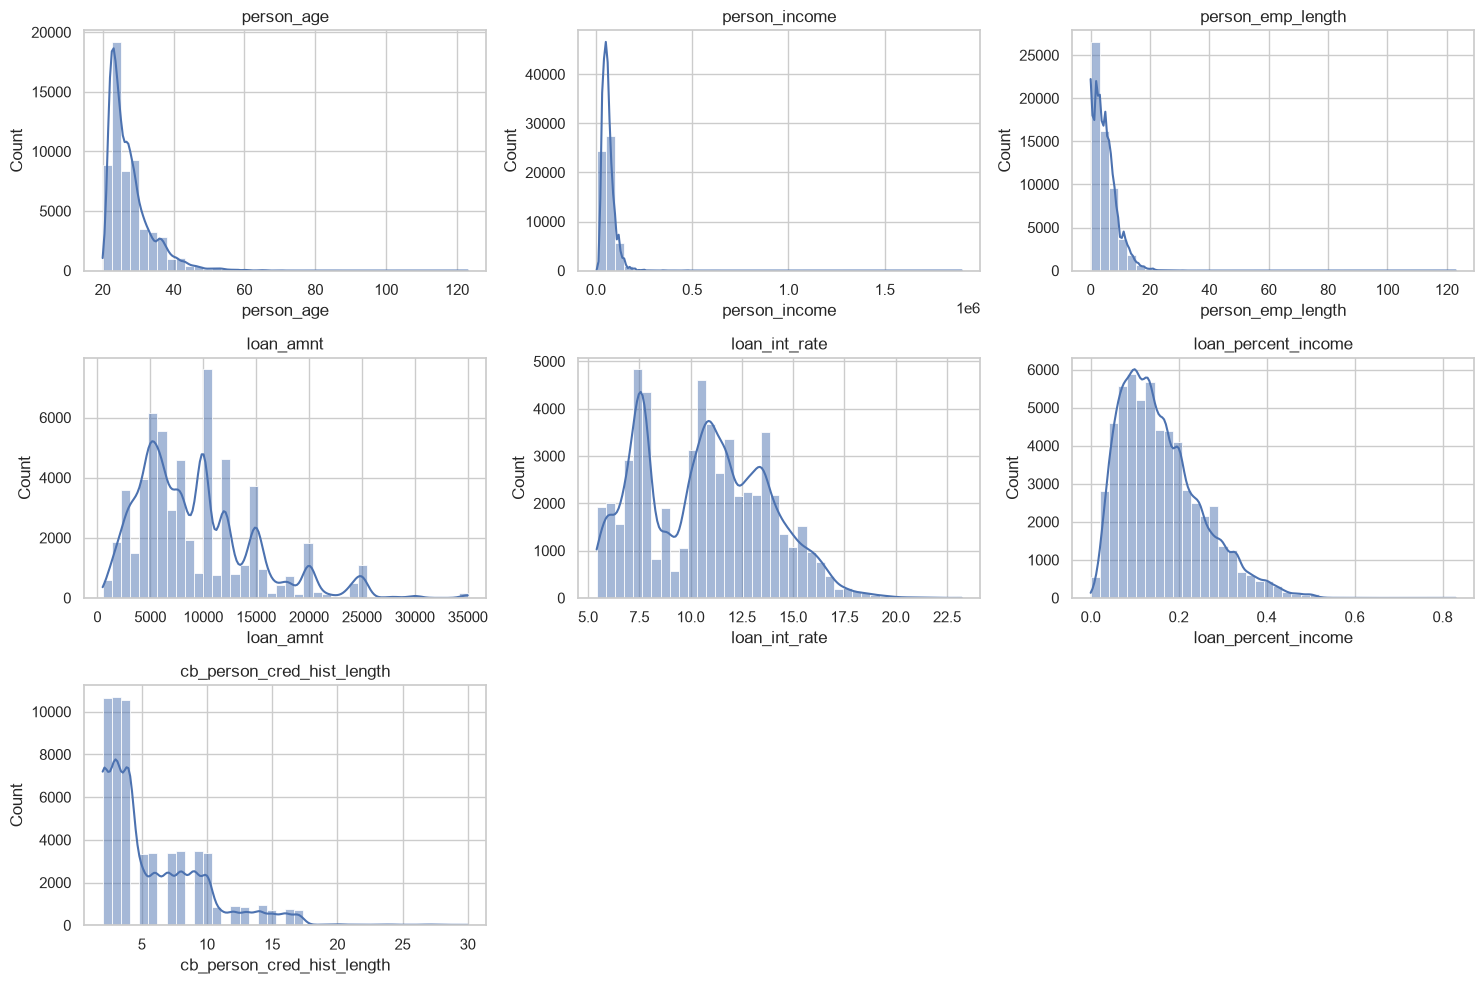

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.histplot(train_raw[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


In [7]:
train_raw[NUMERIC_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00


Ahí están: `person_age` tiene gente de más de 120 años (obviamente un error de carga de
datos) y `person_emp_length` también se va por encima de 60 años de experiencia, lo cual
no tiene sentido para alguien que a la vez tiene 20-30 años. Los recorto en vez de tirar
esas filas — en `clean_outliers()` dentro de `src/features.py` — porque el test set también
tiene casos así y no me puedo dar el lujo de no predecirlos.


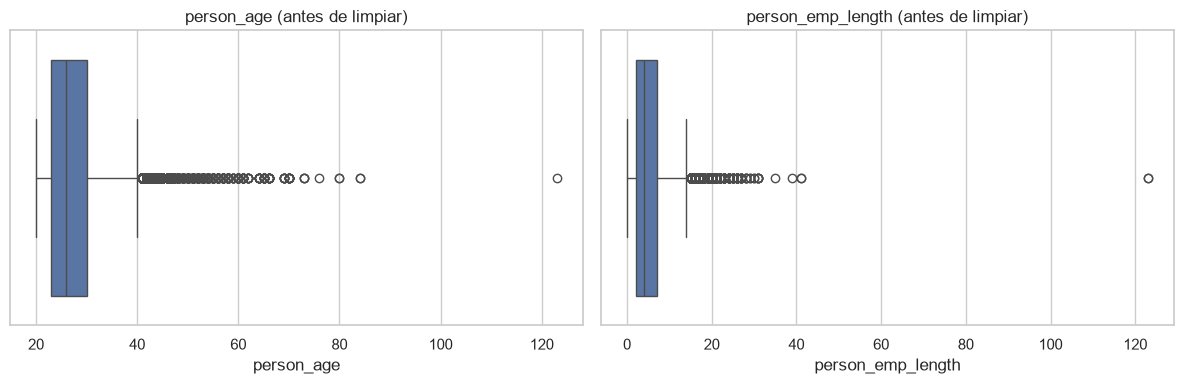

Registros con person_age > 80: 3
Registros con person_emp_length > 60: 2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=train_raw["person_age"], ax=axes[0])
axes[0].set_title("person_age (antes de limpiar)")
sns.boxplot(x=train_raw["person_emp_length"], ax=axes[1])
axes[1].set_title("person_emp_length (antes de limpiar)")
plt.tight_layout()
plt.show()

print("Registros con person_age > 80:", (train_raw["person_age"] > 80).sum())
print("Registros con person_emp_length > 60:", (train_raw["person_emp_length"] > 60).sum())


## Categóricas contra el target

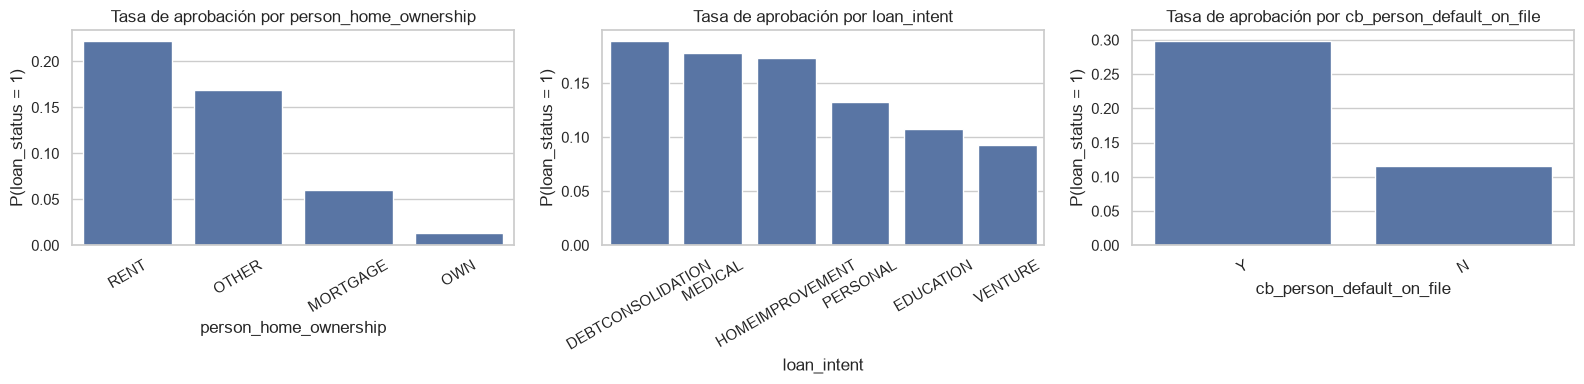

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    rate = train_raw.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Tasa de aprobación por {col}")
    ax.set_ylabel("P(loan_status = 1)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


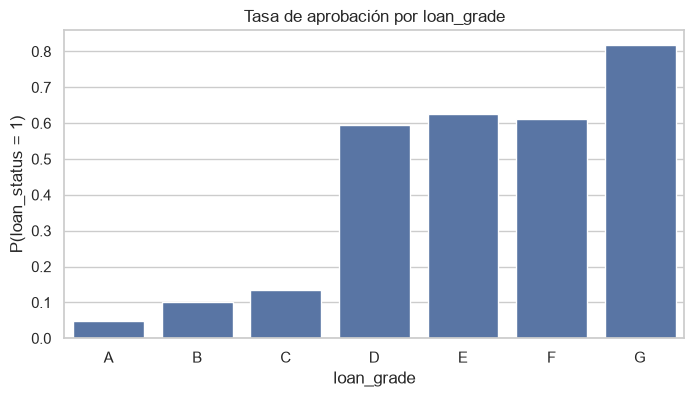

In [10]:
rate_grade = train_raw.groupby("loan_grade")[TARGET].mean().sort_index()
ax = sns.barplot(x=rate_grade.index, y=rate_grade.values)
ax.set_title("Tasa de aprobación por loan_grade")
ax.set_ylabel("P(loan_status = 1)")
plt.show()


Esto es lo más claro que vi en todo el EDA: `loan_grade` sube de A a G prácticamente en
línea recta con la probabilidad de que el target sea 1. Tiene todo el sentido (la letra
ya es una medida de riesgo), así que en vez de tratarla como una categórica cualquiera la
paso a ordinal (A=0 ... G=6) para que el modelo no pierda ese orden.


## Correlaciones entre las numéricas

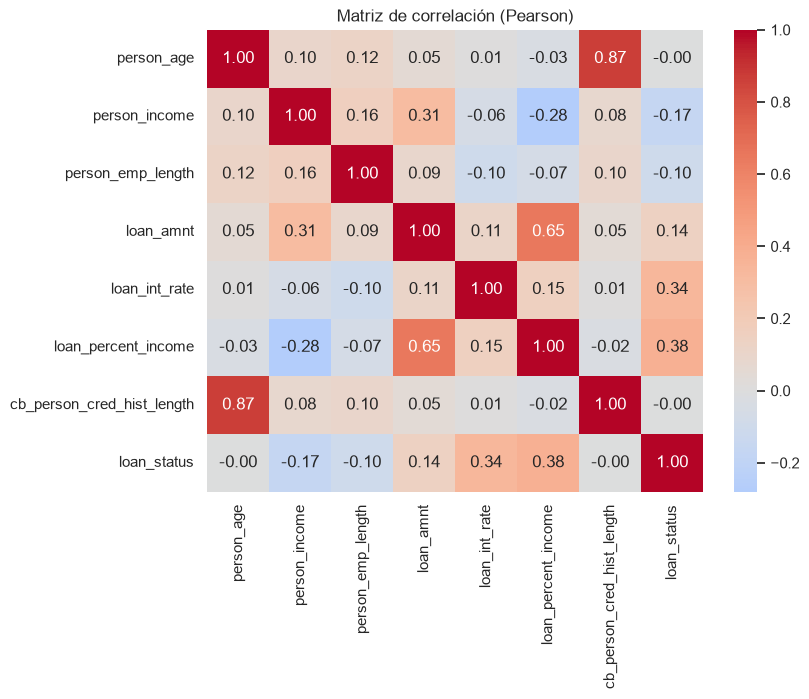

In [11]:
corr = train_raw[NUMERIC_COLS + [TARGET]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Pearson)")
plt.show()


`loan_percent_income` y `loan_int_rate` son las que más se mueven con el target. Tiene
lógica: cuanto más pesa el préstamo sobre lo que ganas y más alta la tasa que te ponen
(que ya de por sí refleja el riesgo que te asignaron), más probable que quede como 1.


## Features nuevas

In [12]:
train = build_model_frame(train_raw)
test = build_model_frame(test_raw)

cols = feature_columns()
print(f"Total de features usadas por el modelo: {len(cols)}")
cols


Total de features usadas por el modelo: 26


['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'loan_grade_ordinal',
 'income_to_loan_ratio',
 'credit_history_ratio',
 'age_emp_ratio',
 'income_per_year_employed',
 'log_person_income',
 'log_loan_amnt',
 'person_home_ownership_MORTGAGE',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_DEBTCONSOLIDATION',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'cb_person_default_on_file_N',
 'cb_person_default_on_file_Y']

In [13]:
train[cols + [TARGET]].head()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_grade_ordinal,income_to_loan_ratio,credit_history_ratio,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_N,cb_person_default_on_file_Y,loan_status
0,37,35000,0.0,6000,11.49,0.17,14,1,5.832361,0.368421,...,1,0,1,0,0,0,0,1,0,0
1,22,56000,6.0,4000,13.35,0.07,2,2,13.996501,0.086957,...,0,0,0,0,1,0,0,1,0,0
2,29,28800,8.0,6000,8.90,0.21,10,0,4.799200,0.333333,...,0,0,0,0,0,1,0,1,0,0
3,30,70000,14.0,12000,11.11,0.17,5,1,5.832847,0.161290,...,1,0,0,0,0,0,1,1,0,0
4,22,60000,2.0,6000,6.92,0.10,3,0,9.998334,0.130435,...,1,0,0,0,1,0,0,1,0,0


Además de lo que ya venía en el dataset, agregué estas (todo vive en `src/features.py`,
para no repetir la lógica entre el notebook y el script de entrenamiento):

- `loan_grade_ordinal`: la letra A-G pasada a número 0-6.
- `income_to_loan_ratio`: ingreso sobre monto del préstamo, como proxy de capacidad de pago.
- `credit_history_ratio`: años de historial crediticio sobre edad — cuánta "vida crediticia"
  relativa tiene la persona.
- `age_emp_ratio`: parecido pero con años de empleo.
- `income_per_year_employed`: ingreso normalizado por experiencia laboral.
- `log_person_income` y `log_loan_amnt`: log1p, porque ambas tienen una cola bien larga a
  la derecha y así ayudo un poco a los modelos lineales.


## Modelos

Para validar uso Stratified K-Fold con 5 folds, manteniendo la proporción de clases en
cada uno. Voy a probar dos cosas:

1. Una regresión logística de referencia, para tener un piso con el que comparar.
2. LightGBM, que suele ir bien en este tipo de datos tabulares.

Las tres categóricas (`person_home_ownership`, `loan_intent`, `cb_person_default_on_file`)
ya llegan como columnas one-hot desde `feature_columns()` (categorías fijas, ver
`src/features.py`), así que `X` queda 100% numérico desde el principio — nada de
`categorical_feature` de LightGBM ni `OneHotEncoder` acá. Lo hice así a propósito: el
tipo `category` de pandas no sobrevive bien el viaje por JSON cuando el modelo se sirve
como API más adelante, y prefiero que el mismo dataframe le sirva a los dos modelos.


In [14]:
X = train[cols].copy()
y = train[TARGET].values
X_test = test[cols].copy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


### Regresión logística (referencia)

In [15]:
lr_oof = np.zeros(len(X))
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(X.iloc[tr_idx], y[tr_idx])
    lr_oof[va_idx] = pipe.predict_proba(X.iloc[va_idx])[:, 1]

lr_auc = roc_auc_score(y, lr_oof)
print(f"Regresión Logística — AUC out-of-fold: {lr_auc:.5f}")


Regresión Logística — AUC out-of-fold: 0.89873


### LightGBM

In [16]:
lgbm_oof = np.zeros(len(X))
lgbm_test_preds = np.zeros(len(X_test))
fold_aucs = []
models = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model.fit(
        X.iloc[tr_idx], y[tr_idx],
        eval_X=X.iloc[va_idx], eval_y=y[va_idx],
        callbacks=[early_stopping(100, verbose=False), log_evaluation(0)],
    )
    val_pred = model.predict_proba(X.iloc[va_idx])[:, 1]
    lgbm_oof[va_idx] = val_pred
    fold_auc = roc_auc_score(y[va_idx], val_pred)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold}/5 — AUC: {fold_auc:.5f} — mejores iteraciones: {model.best_iteration_}")

    lgbm_test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    models.append(model)

lgbm_auc = roc_auc_score(y, lgbm_oof)
print(f"\nLightGBM — AUC promedio por fold: {np.mean(fold_aucs):.5f} (+/- {np.std(fold_aucs):.5f})")
print(f"LightGBM — AUC out-of-fold: {lgbm_auc:.5f}")


Fold 1/5 — AUC: 0.95115 — mejores iteraciones: 305


Fold 2/5 — AUC: 0.96132 — mejores iteraciones: 359


Fold 3/5 — AUC: 0.95432 — mejores iteraciones: 355


Fold 4/5 — AUC: 0.95975 — mejores iteraciones: 471


Fold 5/5 — AUC: 0.95785 — mejores iteraciones: 249

LightGBM — AUC promedio por fold: 0.95688 (+/- 0.00370)
LightGBM — AUC out-of-fold: 0.95676


### ¿Cuál gana?

In [17]:
results = pd.DataFrame({
    "modelo": ["Regresión Logística (baseline)", "LightGBM (5-fold CV)"],
    "AUC_oof": [lr_auc, lgbm_auc],
}).sort_values("AUC_oof", ascending=False).reset_index(drop=True)
results


,modelo,AUC_oof
0,LightGBM (5-fold CV),0.956756
1,Regresión Logística (baseline),0.898734


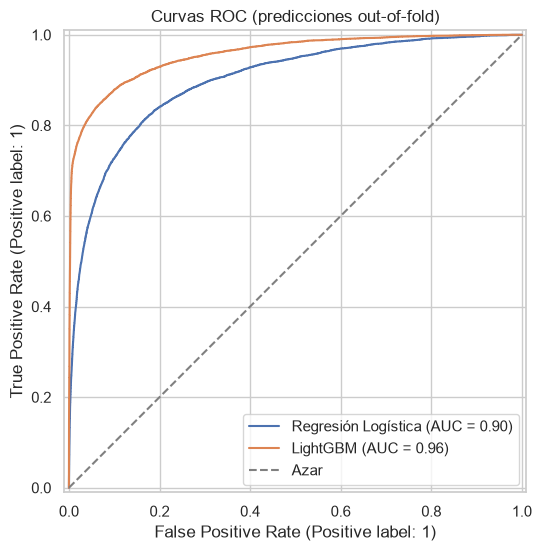

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y, lr_oof, name="Regresión Logística", ax=ax)
RocCurveDisplay.from_predictions(y, lgbm_oof, name="LightGBM", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curvas ROC (predicciones out-of-fold)")
ax.legend()
plt.show()


LightGBM le saca bastante ventaja a la regresión logística (0.9567 vs 0.8987 de AUC), lo
cual tampoco me sorprende tanto: hay interacciones entre `loan_grade`, `loan_int_rate` y
`loan_percent_income` que un modelo lineal simplemente no puede capturar. Me quedo con
LightGBM como modelo final.


## ¿Qué variables pesan más?

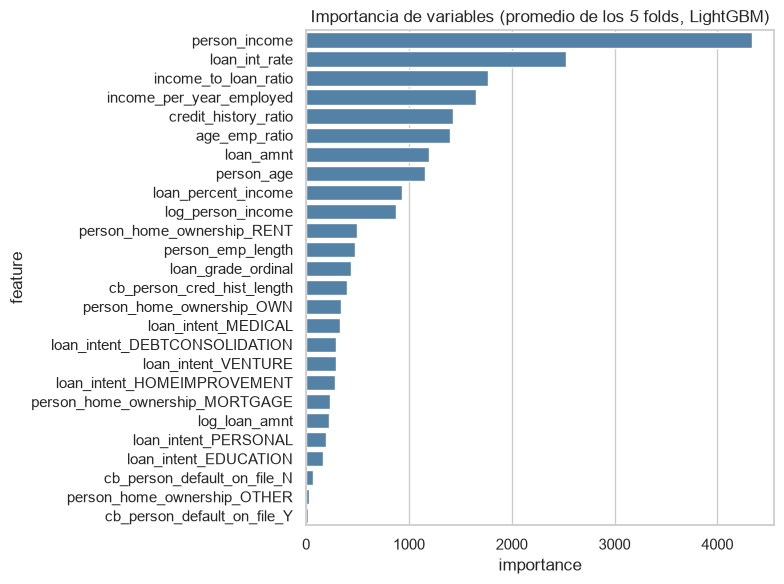

,feature,importance
1,person_income,4334.2
4,loan_int_rate,2528.6
8,income_to_loan_ratio,1773.8
11,income_per_year_employed,1650.2
9,credit_history_ratio,1432.2
10,age_emp_ratio,1400.8
3,loan_amnt,1195.6
0,person_age,1152.4
5,loan_percent_income,935.8
12,log_person_income,875.8


In [19]:
importances = pd.DataFrame({
    "feature": cols,
    "importance": np.mean([m.feature_importances_ for m in models], axis=0),
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importances, x="importance", y="feature", color="steelblue")
plt.title("Importancia de variables (promedio de los 5 folds, LightGBM)")
plt.tight_layout()
plt.show()

importances


## Generando el submission

Uso el promedio de los 5 modelos de la validación cruzada para predecir sobre test, en
vez de reentrenar uno solo con el 100% del train — en la práctica ese promedio (un
mini-ensamble gratis) suele generalizar un poco mejor.


In [20]:
submission = sample_submission.copy()
submission[TARGET] = lgbm_test_preds

submission.to_csv("../submissions/submission.csv", index=False)
submission.head()


,id,loan_status
0,58645,0.990594
1,58646,0.012779
2,58647,0.647648
3,58648,0.011800
4,58649,0.060703


In [21]:
print("Filas en submission:", len(submission))
print("Rango de probabilidades predichas:", submission[TARGET].min(), "-", submission[TARGET].max())


Filas en submission: 39098
Rango de probabilidades predichas: 0.00047783273210770305 - 0.9971452206783393


## Cierre

En resumen: los datos venían bastante limpios salvo por un par de outliers claros en edad
y años de empleo, que corregí acotándolos. `loan_grade`, `loan_percent_income` y
`loan_int_rate` terminaron siendo, como esperaba por la intuición del dominio, las
variables que más pesan a la hora de predecir si una solicitud queda marcada como riesgosa.

LightGBM (AUC 0.9567 out-of-fold)


## MLOps: tracking con MLflow y despliegue con Docker

Hasta acá todo quedó en el notebook, pero para la rama de MLOps necesito dos cosas más:
que quede registrado en MLflow (params, métricas y el modelo en sí) y que el modelo se
pueda llamar como una API real, corriendo dentro de un contenedor Docker.

Toda la lógica de entrenamiento + logging a MLflow la tengo en `src/train.py` (así no
la vuelvo a escribir acá encima); lo que hago en esta sección es correrla y mostrar qué
queda registrado.


### Entrenando y registrando en MLflow

`src/train.py` hace tres cosas y cada una queda como un run separado en el experimento
`loan-approval-prediction`:

1. `baseline-logreg` — la regresión logística de referencia.
2. `lightgbm-cv` — la validación cruzada de LightGBM, con la métrica por fold.
3. `lightgbm-final` — LightGBM reentrenado sobre el 100% del train, que es el que se
   registra en el Model Registry (`loan-approval-lgbm`) y el que se guarda en `model/`
   listo para servir.

El tracking store es un sqlite (`mlflow.db`) en la raíz del proyecto, así da igual si
corro esto desde el notebook o desde consola — todo cae en el mismo sitio y se ve junto
en `mlflow ui`.


In [22]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "train.py"],
    cwd="../src",
    capture_output=True,
    text=True,
)
print(result.stdout[-1500:])
if result.returncode != 0:
    print(result.stderr[-2000:])


Regresión logística — AUC out-of-fold: 0.89873
Fold 1/5 AUC: 0.95115
Fold 2/5 AUC: 0.96132
Fold 3/5 AUC: 0.95432
Fold 4/5 AUC: 0.95975
Fold 5/5 AUC: 0.95785

CV AUC out-of-fold: 0.95676
Modelo final guardado en: C:\Users\Jaime\Desktop\MASTER\python\Loan-Approval-Prediction-\loan-approval-prediction\model (n_estimators=347)
Submission guardado en: C:\Users\Jaime\Desktop\MASTER\python\Loan-Approval-Prediction-\loan-approval-prediction\submissions\submission.csv



Y así se ven los runs que acabo de generar, consultándolos directamente con el cliente
de MLflow (lo mismo que se ve, con más detalle visual, en `mlflow ui`):


In [23]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
client = mlflow.MlflowClient()

experiment = client.get_experiment_by_name("loan-approval-prediction")
runs = client.search_runs([experiment.experiment_id], order_by=["start_time DESC"])

runs_df = pd.DataFrame([
    {"run_name": r.data.tags.get("mlflow.runName"), **r.data.metrics}
    for r in runs
])
runs_df


2026/09/23 19:57:11 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\Jaime\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


,run_name,fold_auc,auc_oof,auc_mean,auc_std
0,lightgbm-final,NaN,NaN,NaN,NaN
1,lightgbm-cv,0.957853,0.956756,0.956878,0.003695
2,baseline-logreg,NaN,0.898734,NaN,NaN


Para ver esto mismo con gráficos y comparando runs entre sí, se levanta la UI de MLflow
con:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

y se abre en `http://127.0.0.1:5000`.


### Despliegue con Docker

El `Dockerfile` (en la raíz del proyecto) no entrena nada — solo empaqueta el modelo que
ya quedó guardado en `model/` junto con lo mínimo para servirlo, y arranca
`mlflow models serve` al levantar el contenedor. Los pasos son:

```bash
# 1. Construir la imagen
docker build -t loan-approval-api .

# 2. Levantar el contenedor, publicando el puerto 5000
docker run -p 5000:5000 loan-approval-api
```

Con eso, el contenedor queda escuchando en `http://localhost:5000/invocations`, que es
el endpoint estándar que expone MLflow para pedir predicciones.

*Nota: en el entorno donde escribí este notebook no tengo Docker instalado, así que no
pude hacer el `docker build` real. Lo que sí hice fue levantar el mismo servidor
(`mlflow models serve`, el comando exacto que corre el `CMD` del Dockerfile) directamente
en esta máquina para probar que el endpoint funciona de verdad — es el mismo proceso que
correría dentro del contenedor, solo que sin la capa de Docker encima.*


### Probando el modelo desplegado

Levanto el servidor (el mismo comando que usa el Dockerfile) como subproceso, espero a
que responda, y le mando una solicitud real con tres registros de test para que devuelva
la probabilidad de aprobación de cada uno.


In [24]:
import os
import site
import subprocess
import sys
import time

# El instalador de pip dejó los ejecutables (mlflow, uvicorn) en la carpeta Scripts del
# usuario, que no está en el PATH por defecto en esta máquina — la agrego para este
# subproceso.
scripts_dir = os.path.join(os.path.dirname(site.getusersitepackages()), "Scripts")
env = os.environ.copy()
env["PATH"] = scripts_dir + os.pathsep + env.get("PATH", "")
env["MLFLOW_TRACKING_URI"] = "sqlite:///../mlflow.db"

server = subprocess.Popen(
    ["mlflow", "models", "serve", "-m", "../model", "--host", "127.0.0.1", "--port", "5001",
     "--env-manager", "local"],
    cwd=".",
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)


In [25]:
import requests

server_ready = False
for _ in range(30):
    try:
        if requests.get("http://127.0.0.1:5001/ping", timeout=2).status_code == 200:
            server_ready = True
            break
    except requests.exceptions.ConnectionError:
        pass
    time.sleep(2)

print("Servidor arriba:" if server_ready else "El servidor no respondió a tiempo", server_ready)


Servidor arriba: True


In [26]:
# Tres solicitudes reales de test.csv, procesadas con el mismo pipeline de features
# que usa el modelo (build_model_frame + feature_columns), tal como llegarían en
# producción.
sample = build_model_frame(test_raw.head(3))
X_sample = sample[cols]

payload = {"dataframe_split": {"columns": cols, "data": X_sample.values.tolist()}}

response = requests.post("http://127.0.0.1:5001/invocations", json=payload)
print("Status:", response.status_code)
print("Predicciones (probabilidad de aprobación):", response.json())


Status: 200
Predicciones (probabilidad de aprobación): {'predictions': [0.993288742885788, 0.012910391811262313, 0.6410633159217249]}


Ahí está: el endpoint devuelve la probabilidad de aprobación para cada solicitud
(`predict_proba`, no solo la clase 0/1), que es el mismo tipo de score que usé para
armar el submission. Cierro el servidor de prueba para no dejarlo corriendo de fondo.


In [27]:
server.terminate()
try:
    server.wait(timeout=10)
except subprocess.TimeoutExpired:
    server.kill()
print("Servidor de prueba detenido.")


Servidor de prueba detenido.
